# Basic Statistic

This notebook loads some data, reports simple descriptive statistics (means, standard deviations etc) and shows a number of useful plots (scatter plots, histograms, time series plots). 

The approach is fast-paced, and details are left for later notebooks.

Most of the descriptive stats use the standard package `Statistics`. The plots rely on the [Plots.jl](https://github.com/JuliaPlots/Plots.jl) package and the pdf and quantiles are from the [Distributions.jl](https://github.com/JuliaStats/Distributions.jl) package.

For more stat functions, see the [StatsBase.jl](https://github.com/JuliaStats/StatsBase.jl) package (not used here).

Statistical calculations are often reported in tables. This notebook uses my own `printmat()` function. For more powerful alternatives, consider the [PrettyTables.jl](https://github.com/ronisbr/PrettyTables.jl) package.

## Load Packages and Extra Functions

In [1]:
using Statistics, Printf, Dates, LinearAlgebra, DelimitedFiles, Distributions

include("src/printmat.jl")

@doc2

In [2]:
using Plots
default(size = (480,320),fmt = :png)     #change to :svg for sharper plots

# Load Data from a csv File

The next cell loads data (excess returns) from a csv. See the header line for definitions. To keep it simple, the cell creates the variables in a rather crude way (picking out columns).

In [3]:
x = readdlm("Data/TwoIndustries.csv",',',skipstart=1)

(dN,R) = (Date.(x[:,1]),Float64.(x[:,2:4]))   #make sure dN is a Date, and data is Float
printlnPs("R: ",size(R))   #Re: excess returns on two sectors and the equity market

RNames = ["HiTec","Utils","Market"];     #names of the (columns) in the `R` matrix, see header line
printmat(RNames)
(T,n) = size(R)                          #no. of periods and variables

       R:   (660, 3)
     HiTec
     Utils
    Market



(660, 3)

# Descriptive Statistics

## Means and Standard Deviations

The next few cells estimate means, standard deviations, quantiles, covariances and correlation.

In [4]:
μ   = mean(R,dims=1)    #,dims=1 to calculate average along a column
σ   = std(R,dims=1)     #do \sigma[Tab] to get σ

printmat([μ;σ];colNames=RNames,rowNames=["mean","std"])

         HiTec     Utils    Market
mean     0.700     0.547     0.608
std      6.538     4.151     4.599



## Quantiles

The `quantile()` function has no `dims` argument, so we need to loop over the columns. This can be done in several ways, and the cell uses a very straightforward approach.

In [5]:
qM = fill(NaN,2,n)
for i in 1:n
    qM[:,i] = quantile(R[:,i],[0.05,0.95])
end

printmat(qM;colNames=RNames,rowNames=["0.05","0.95"])

         HiTec     Utils    Market
0.05    -9.891    -6.333    -7.684
0.95    11.533     6.750     7.191



## Correlations

In [6]:
printblue("\n","correlation matrix:")
printmat(cor(R);colNames=RNames,rowNames=RNames)


correlation matrix:
           HiTec     Utils    Market
HiTec      1.000     0.333     0.870
Utils      0.333     1.000     0.576
Market     0.870     0.576     1.000



# Regressions

The function defined in the next cell calculates the OLS estimates, with standard errors based on iid (Gauss-Markov) assumptions.

The second cell applies the function.

In [7]:
"""
    OLS(y,x)

Does OLS of the regression y = x*b + u

"""
function OLS(y,x)
    b    = x\y                       #OLS
    u    = y - x*b                   #residuals
    covb = inv(x'x)*var(u)           #cov(b), see any textbook
    stdb = sqrt.(diag(covb))         #std(b)
    R2   = 1 - var(u)/var(y)
    return b,stdb,R2
end

OLS

In [8]:
(T,n) = size(R)
x = [ones(T) R[:,3]]          #x is a Tx2 matrix, constant and 'market'
K = size(x,2)                 #no. of regressors, here 2

(b,tstat) = (fill(NaN,K,n),fill(NaN,K,n))    #to fill with results
for i in 1:n
    local stdb
    (b[:,i],stdb,) = OLS(R[:,i],x)
    tstat[:,i] = b[:,i]./stdb
end

printblue("OLS coefficients, regressing R on a constant and Rme:")
printmat(b;colNames=RNames,rowNames=["c","Rme"],width=15)

printblue("t-stats, regressing R on a constant and Rme:")
printmat(tstat[:,1:2];colNames=RNames[1:2],rowNames=["c","Rme"],width=15)

printred("The t-stats for the third regression are uninteresting and extreme")

OLS coefficients, regressing R on a constant and Rme:
             HiTec          Utils         Market
c           -0.052          0.231         -0.000
Rme          1.237          0.520          1.000

t-stats, regressing R on a constant and Rme:
             HiTec          Utils
c           -0.412          1.735
Rme         45.301         18.109

The t-stats for the third regression are uninteresting and extreme


# Distributions

## Probability Density Function (pdf)

The cells below calculate and plot pdfs and cdfs of some distributions. The `Distributions.jl` package has many more distributions.

### A Remark on the Code

- Notice that the `Distributions.jl` package wants `Normal(μ,σ)`, where `σ` is the standard deviation.
- `pdf.(Normal(0,1),x)` calculates the pdf of a standard normal variable at each value in the array `x`. Notice the dot (`.`).

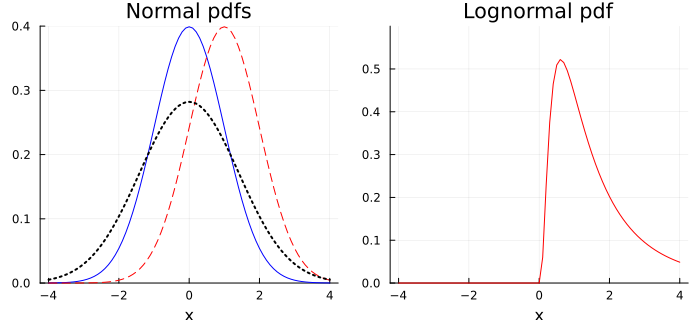

In [9]:
x  = -4:0.1:4
pdf1a  = pdf.(Normal(0,1),x)                     #Normal
pdf1b  = pdf.(Normal(1,1),x) 
pdf1c  = pdf.(Normal(0,sqrt(2)),x)        

pdf2  = pdf.(LogNormal(0.25,sqrt(0.75)),x)       #LogNormal
  

p1 = plot( x,hcat(pdf1a,pdf1b,pdf1c),
           linecolor = [:blue :red :black],
           linestyle = [:solid :dash :dot],
           linewidth = [1 1 2],
           legend = nothing,
           ylims = (0,0.4),
           title = "Normal pdfs",
           xlabel = "x")

p2 = plot( x,pdf2,
           linecolor = :red,
           legend = nothing,
           ylims = (0,0.6),
           title = "Lognormal pdf",
           xlabel = "x")  
 
pAll = plot( p1,p2,                             #combine the subplots
             layout = @layout[a a],
             size = (700,320) )
display(pAll)

Pr(x<=1.645)      0.950


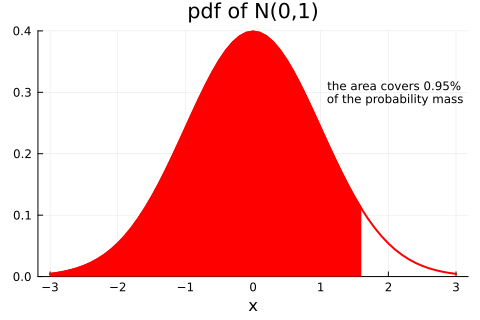

In [10]:
x  = -3:0.1:3
xb = x[x.<=1.645]                  #pick out x values <= 1.645

pdfx  = pdf.(Normal(0,1),x)       #calculate the pdf of a N(0,1) variable
pdfxb = pdf.(Normal(0,1),xb)      #colour the area below this curve
Prb = cdf(Normal(0,1),1.645)
printlnPs("Pr(x<=1.645) ",Prb)

p1 = plot( x,pdfx,                        #plot pdf
           linecolor = :red,
           linewidth = 2,
           legend = nothing,
           ylims = (0,0.4),
           title = "pdf of N(0,1)",
           xlabel = "x",
           annotation = (1.1,0.3,text("the area covers $(round(Prb,digits=2))%\nof the probability mass",:left,8)) )
plot!(xb,pdfxb,linecolor=:red,linewidth=2,legend=nothing,fill=(0,:red))    #plot area under pdf
display(p1)

## Quantiles ("critical values") of Distributions

In [11]:
N95     = quantile(Normal(0,1),0.95)            #from the Distributions package
Chisq90 = quantile(Chisq(2),0.9)

printblue("\n","95th percentile of N(0,1) and 90th of χ²(2):")
printmat([N95 Chisq90])


95th percentile of N(0,1) and 90th of χ²(2):
     1.645     4.605



# Drawing Random Numbers

## Random Numbers: Independent Variables

In [12]:
T = 100
x = randn(T,2)    #T x 2 matrix, N(0,1) distribution

printblue("\n","mean and std of random draws: ")
μ = mean(x,dims=1)
σ = std(x,dims=1)

colNames = ["x₁","x₂"]
printmat([μ;σ];colNames,rowNames=["mean","std"])

printblue("covariance matrix:")
printmat(cov(x);colNames,rowNames=colNames)


mean and std of random draws: 
            x₁        x₂
mean    -0.091     0.026
std      0.911     0.949

covariance matrix:
          x₁        x₂
x₁     0.830    -0.041
x₂    -0.041     0.900



## Random Numbers: Correlated Variables

In [13]:
μ = [-1,10]          #vector of means
Σ = [1 0.5;          #covariance matrix
     0.5 2]

T = 100
x = rand(MvNormal(μ,Σ),T)'  #drawn from bivariate N(μ,Σ), transpose to get T x 2
colNames = ["x₁","x₂"]

printblue("covariance matrix:")
printmat(cov(x);colNames,rowNames=colNames)

covariance matrix:
          x₁        x₂
x₁     1.222     0.656
x₂     0.656     2.004



# Statistical Plots

The next few cells demonstrates some useful statistical plots.

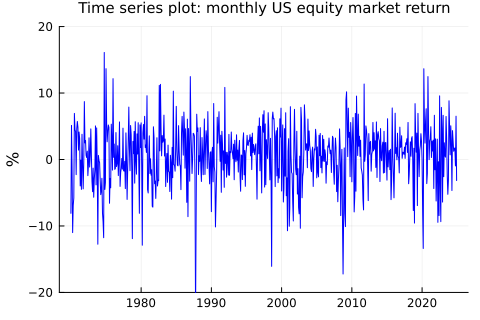

In [14]:
xTicksLoc = Date(1980):Year(10):Date(2020)   #a sequence, to get good x-axis labels
xTicksLab = Dates.format.(xTicksLoc,"Y")

p1 = plot( dN,R[:,3],                        #time series plot 
           linecolor = :blue,
           legend = false,
           xticks = (xTicksLoc,xTicksLab),
           ylim = (-20,20),
           title = "Time series plot: monthly US equity market return",
           titlefontsize = 10,
           ylabel = "%" )
display(p1)

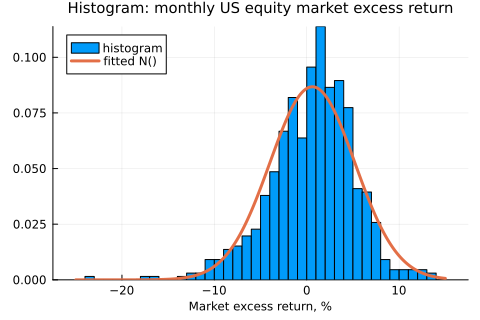

In [15]:
xGrid = -25:0.1:15
pdfX  = pdf.(Normal(mean(R[:,3]),std(R[:,3])),xGrid) #"Distributions" wants σ, not σ^2

p1 = histogram( R[:,3],bins = -25:1:15,     #histogram
                normalized = true,     #normalized to have area=1
                label = "histogram",
                title = "Histogram: monthly US equity market excess return",
                titlefontsize = 10,
                xlabel = "Market excess return, %",
                legend = :topleft,
                guidefontsize = 8 )   #font size of axis labels
plot!(xGrid,pdfX,linewidth=3,label="fitted N()")
display(p1)

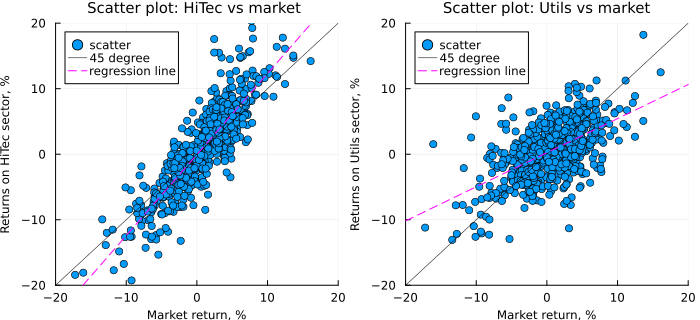

In [16]:
p1 = scatter( R[:,3],R[:,1],               #scatter
              fillcolor = :blue,
              label = "scatter", 
              legend = true,
              xlim = (-20,20),
              ylim = (-20,20),
              title = "Scatter plot: $(RNames[1]) vs market ",
              titlefontsize = 10,
              xlabel = "Market return, %",
              ylabel = "Returns on $(RNames[1]) sector, %",
              guidefontsize = 8 )
Plots.abline!(1,0,color=:black,linewidth=0.5,label="45 degree")                #45-degree line
Plots.abline!(b[2,1],b[1,1],linecolor=:magenta,line=:dash,label="regression line")   #b is from OLS results

p2 = scatter( R[:,3],R[:,2],
              fillcolor = :blue,
              label = "scatter", 
              legend = true,
              xlim = (-20,20),
              ylim = (-20,20),
              title = "Scatter plot: $(RNames[2]) vs market",
              titlefontsize = 10,
              xlabel = "Market return, %",
              ylabel = "Returns on $(RNames[2]) sector, %",
              guidefontsize = 8 )
Plots.abline!(1,0,color=:black,linewidth=0.5,label="45 degree")
Plots.abline!(b[2,2],b[1,2],linecolor=:magenta,line=:dash,label="regression line")

pAll = plot( p1,p2,                             #combine the subplots
             layout = @layout[a a],
             size = (700,320) )
display(pAll)